In [4]:
import numpy as np
import pyemma
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from matplotlib.colors import ListedColormap
import gc
%matplotlib inline

## Step 1
* Importing the featurized data

In [5]:
data = []
fold_in = 'features/'
n_files = len(os.listdir(fold_in))

for j in tqdm(range(1,n_files+1)):
    file_name = 'features/feature_' + str(int(j)) + '.npy'
    data.append(np.load(file_name, allow_pickle = True))

100%|██████████| 210/210 [03:19<00:00,  1.05it/s]


## Step 2
* Calculating tICA

In [6]:
tica = pyemma.coordinates.tica(data, lag = 2150, dim = 10, kinetic_map = True)
tica_obj = tica.get_output()
tica_concat = np.concatenate(tica_obj)

#############################################################
#Clearing some memory to avoid RAM errors.
#############################################################
del data
del tica
gc.collect()

calculate covariances:   0%|          | 0/210 [00:00<?, ?it/s]

getting output of TICA:   0%|          | 0/214 [00:00<?, ?it/s]

102

## Step 3
* Perform k-means clustering

In [7]:
k_clusts = pyemma.coordinates.cluster_kmeans(data = tica_obj, k = 200, max_iter = int(np.sqrt(tica_concat.shape[0])))
clust_trajs = k_clusts.dtrajs
clust_concat = np.concatenate(clust_trajs)
cluster_centres = k_clusts.clustercenters

#############################################################
#Clearing some memory to avoid RAM errors.
#############################################################
del tica_obj
gc.collect()

initialize kmeans++ centers:   0%|          | 0/200 [00:00<?, ?it/s]

kmeans iterations:   0%|          | 0/1442 [00:00<?, ?it/s]

getting output of KmeansClustering:   0%|          | 0/210 [00:00<?, ?it/s]

90

## Step 4
* Check the distribution of k-mean clusters

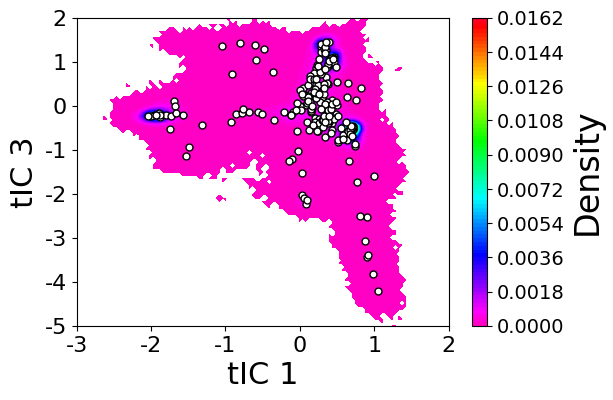

In [8]:
fig, ax = plt.subplots(nrows = 1, ncols =1, figsize = (6,4))
im = pyemma.plots.plot_density(tica_concat[:,0],tica_concat[:,2], ax = ax, cmap = 'gist_rainbow_r', cbar = False)
cbar = fig.colorbar(im[2]['mappable'], ax = ax)
cbar.set_label('Density', fontsize = 24)
cbar.ax.tick_params(labelsize = 14)
cbar.set_label('Density', fontsize = 24)

yticks = [-5, -4, -3, -2, -1, 0, 1, 2]
xticks = [-3, -2, -1, 0, 1, 2]
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(xticks, fontsize = 16)
ax.set_yticklabels(yticks, fontsize = 16)
ax.set_xlim(-3,2)
ax.set_ylim(-5,2)

ax.set_ylabel('tIC 3', fontsize = 22)
ax.set_xlabel('tIC 1', fontsize = 22)

ax.scatter(cluster_centres[:,0], cluster_centres[:,2], s = 25, color = 'w', edgecolor = 'k')

## Step 5 
* Calculate Implied Timescales to find Markovian lag time

estimating BayesianMSM:   0%|          | 0/10 [00:00<?, ?it/s]

Text(0.5, 0, 'Lag Time (ns)')

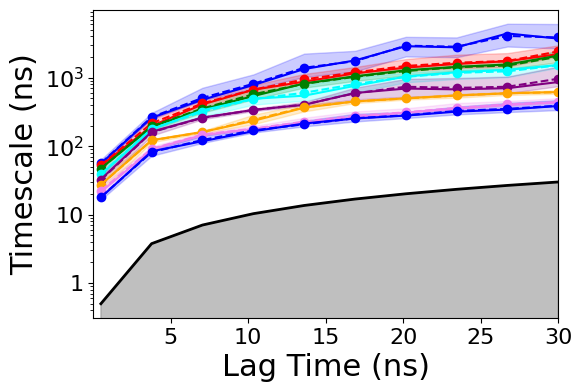

In [9]:
trial_lags = np.int16(np.linspace(50,3000,10))
imp_time = pyemma.msm.its(k_clusts.dtrajs, lags = trial_lags, errors = 'bayes')

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))
pyemma.plots.plot_implied_timescales(imp_time, nits = 8, ax = ax)

yticks = [100,1000,10000,100000]
ytick_labs = ['1','10','10$^2$','10$^3$']
#Frames are saved every 10 ps. So, divide by 100 to get timescales in ns. 

xticks = [500,1000,1500, 2000, 2500, 3000]
xtick_labs = [5, 10, 15, 20, 25, 30]
#Frames are saved every 10 ps. So, divide by 100 to get timescales in ns. 

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labs, fontsize = 16)
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labs, fontsize = 16)

ax.set_ylabel('Timescale (ns)', fontsize = 22)
ax.set_xlabel('Lag Time (ns)', fontsize = 22)

## Step 6 
* Build the MSM and perform spectral analysis

pyemma.msm.estimators.bayesian_msm.BayesianMSM[7]: compute stat. inefficiencies:   0%|          | 0/12136 [00:…

pyemma.msm.estimators.bayesian_msm.BayesianMSM[7]: Sampling MSMs:   0%|          | 0/100 [00:00<?, ?it/s]

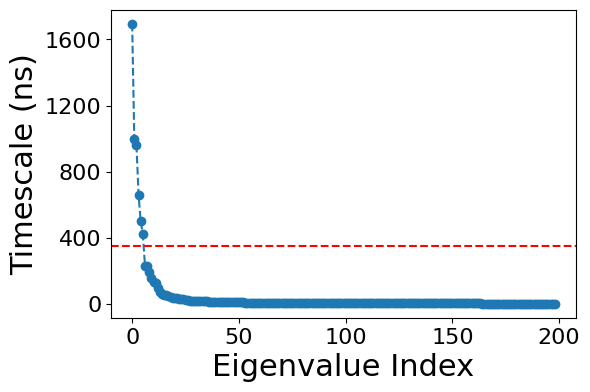

In [10]:
M = pyemma.msm.bayesian_markov_model(k_clusts.dtrajs, 1500)
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

ax.plot(M.timescales(), linestyle = '--', marker = 'o')

yticks = [0, 40000, 80000, 120000, 160000]
ytick_labs = [0, 400, 800, 1200, 1600]
#Frames are saved every 10 ps. So, divide by 100 to get timescales in ns. 

xticks = [0, 50, 100, 150, 200]

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labs, fontsize = 16)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, fontsize = 16)

ax.set_ylabel('Timescale (ns)', fontsize = 22)
ax.set_xlabel('Eigenvalue Index', fontsize = 22)
ax.axhline(y = 35000, color = 'r', linestyle = '--', linewidth = 1.5)

## Step 7 
* Chapman-Kolmogrovv test to validate the macrostates and MSM 

estimating BayesianMSM:   0%|          | 0/4 [00:00<?, ?it/s]

/nethome/asridhar/software/python3.8/lib/python3.8/site-packages/msmtools/analysis/api.py:367: UserWarning: truncated eigendecomposition to contain 198 components
  warnings.warn('truncated eigendecomposition to contain %s components' % new_k, category=UserWarning)


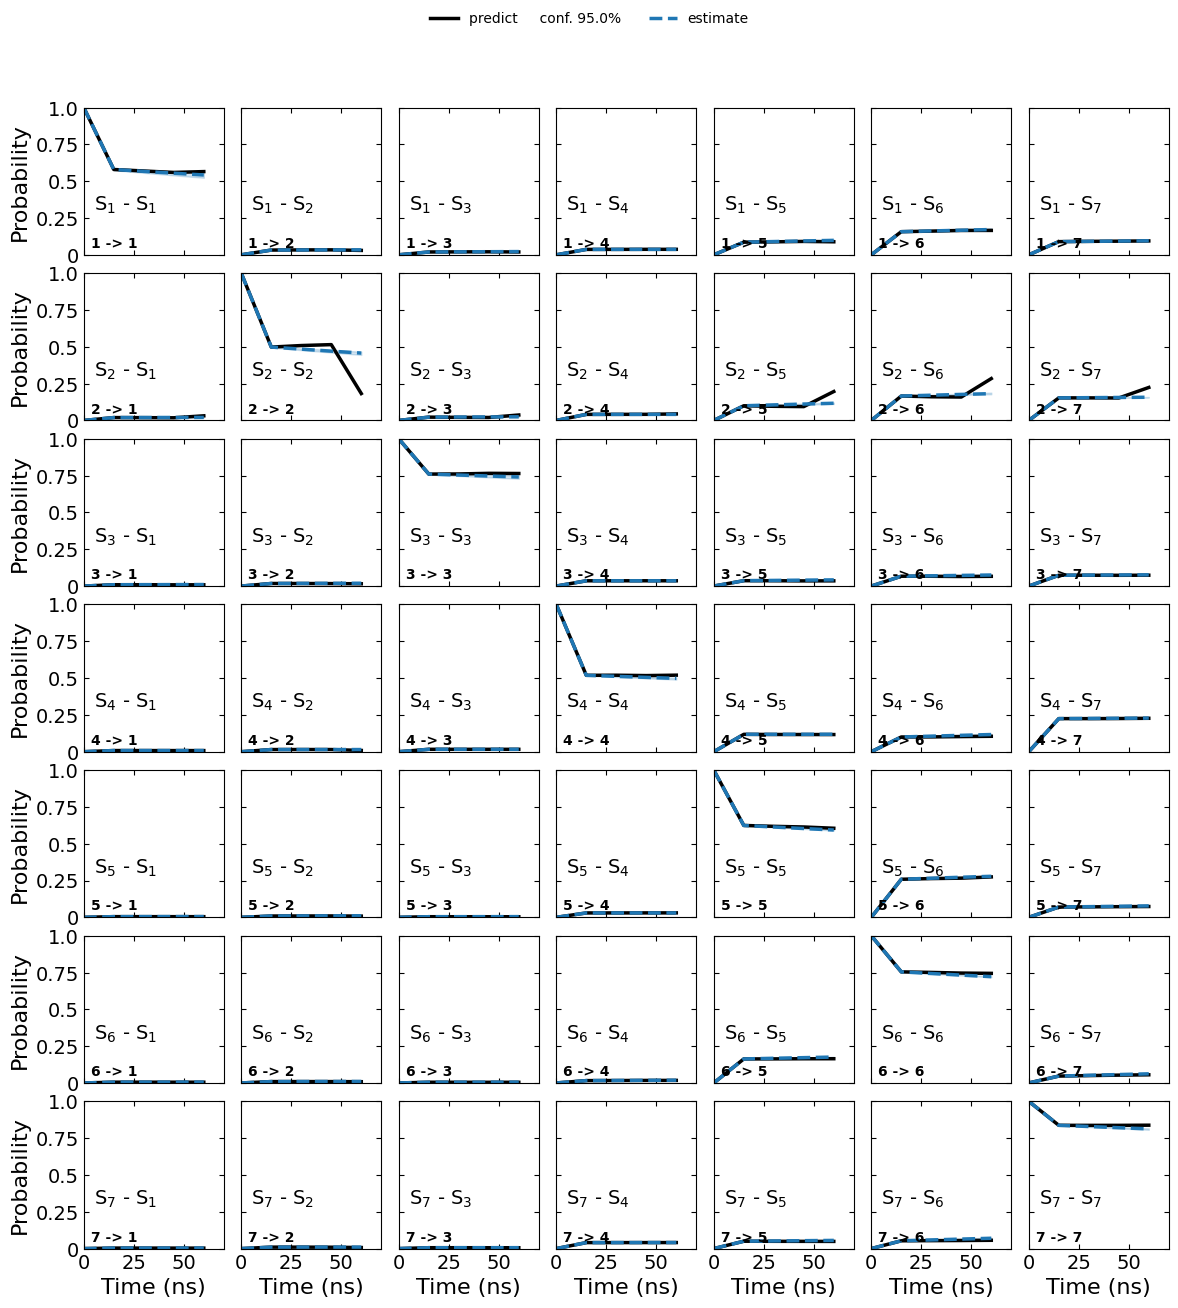

In [11]:
ck = M.cktest(7, mlags = 5)
fig, ax = pyemma.plots.plot_cktest(ck, linewidth = 2.5, figsize = (14,14), y01 = True, padding_between = 0.125)

xticks = [0,2500,5000]
xticklabs = [0,25,50]
#Frames are saved every 10 ps. So, divide by 100 to get timescales in ns. 

yticks = [0,0.25,0.5,0.75,1.0]
for i in range(7):
    for j in range(7):
        ax[i][j].set_xticks(xticks)
        ax[i][j].set_yticks(yticks)
        ax[i][j].tick_params(axis = 'x', direction = 'in', bottom = True, top = True)
        ax[i][j].tick_params(axis = 'y', direction = 'in', left = True, right = True, which = 'both')
        ax[i][j].set_xlim(0,7000)
        ax[i][j].set_ylim(0,1.0)
       
        txt = 'S$_{' + str(int(i+1)) + '}$ - S$_{' + str(int(j+1)) + '}$'
        ax[i][j].text(500,0.3, txt, fontsize = 14)
        
        if j == 0:
            ax[i][j].set_yticklabels(yticks, fontsize = 14)
            ax[i][j].set_ylabel('Probability', fontsize = 16)
     
        if i == 6:
            ax[i][j].set_xticklabels(xticklabs, fontsize = 14)
            ax[i][j].set_xlabel('Time (ns)', fontsize = 16)
        else:
            ax[i][j].set_xticklabels([])

## Step 8
* Perform PCCA++ on the number of macrostates = 7.
* Assign trajectory frames to a macrostate if PCCA probability > 80%.
* Calculate the weights of the trajectory frames. 

In [12]:
M.pcca(7)
pcca_probs = M.metastable_memberships[clust_concat]
clust_assign = np.zeros((pcca_probs.shape[0]), dtype = int)

for i in range(pcca_probs.shape[0]):
    if np.amax(pcca_probs[i,:]) > 0.80:
        clust_assign[i] = np.argmax(pcca_probs[i,:]) + 1        


wts = M.trajectory_weights()
wts_concat = np.concatenate(wts)

## Step 9
* Calculate the stationary probability distribution of the seven macrostates. 

In [13]:
pi = np.zeros((7), dtype = float)
for i,s in enumerate(M.metastable_sets):
    pi[i] = M.pi[s].sum()

for i in range(len(pi)):
    out = 'Cluster ' + str(int(i + 1)) + ' : Weight ' + str(round(pi[i], 2))
    print(out)

Cluster 1 : Weight 0.01
Cluster 2 : Weight 0.01
Cluster 3 : Weight 0.02
Cluster 4 : Weight 0.03
Cluster 5 : Weight 0.17
Cluster 6 : Weight 0.46
Cluster 7 : Weight 0.29


## Step 10
* Compare the projection of seven macrostates along the free energy surface. 

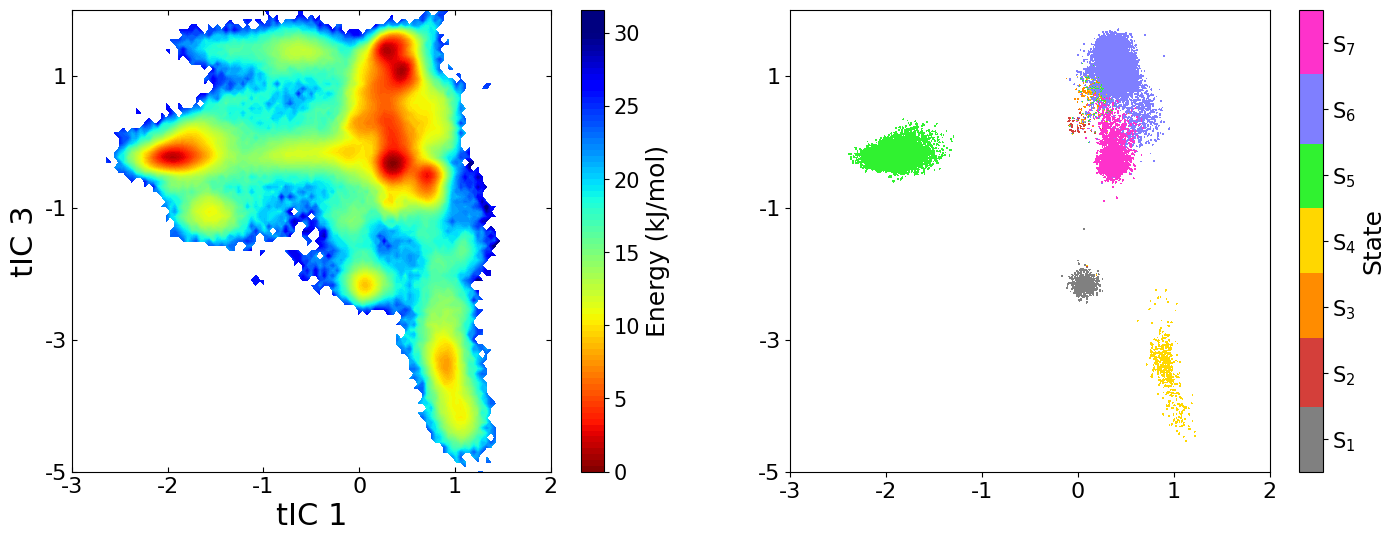

In [14]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (17,6), sharex = False, sharey = False)
###################################################################################################
# Plotting the FES along tIC1 and tIC3
###################################################################################################
im = pyemma.plots.plot_free_energy(tica_concat[:,0],tica_concat[:,2], cmap = 'jet_r', cbar = True, weights = wts_concat, cbar_label = None, kT = 2.479, legacy = False, ax = ax[0], vmin = 0, vmax = 30)
#Beautifying the plot below this.
yticks = [-5, -3, -1, 1]
xticks = [-3, -2, -1, 0, 1, 2]
ax[0].set_xticks(xticks)
ax[0].set_yticks(yticks)
ax[0].set_xticklabels(xticks, fontsize = 16)
ax[0].set_yticklabels(yticks, fontsize = 16)
ax[0].set_xlim(-3,2)
ax[0].set_ylim(-5,2)
ax[0].tick_params(axis = 'y', direction = 'in', left = True, right = True)
ax[0].tick_params(axis = 'x', direction = 'in', bottom = True, top = True)
ax[0].set_xlabel('tIC 1', fontsize = 22)
ax[0].set_ylabel('tIC 3', fontsize = 22)

cbar_ticks = [0, 5, 10, 15, 20, 25, 30]
im[2]['cbar'].set_ticks(cbar_ticks)
im[2]['cbar'].set_label('Energy (kJ/mol)', size = 18)
im[2]['cbar'].ax.tick_params(labelsize = 15)

###################################################################################################
#Now plotting the state map
#We reduce the number of data points to 75000 for a clearer plot. 
###################################################################################################
clear_assignments = clust_assign[np.nonzero(clust_assign)] - 1
tica_cut = tica_concat[np.nonzero(clust_assign),:]

subset_inds = np.sort(np.unique(np.random.choice(tica_cut.shape[1], 75000)))

cm = ListedColormap(['grey','#D43F3A','darkorange', 'gold' ,'#30F230', '#7F7FFF', '#FE32CB'])
im2 = pyemma.plots.plot_state_map(tica_cut[0,subset_inds,0], tica_cut[0,subset_inds,2], clear_assignments[subset_inds], nbins = 500, cbar = True, ax = ax[1], cbar_label = None, cmap = cm, alpha = 1)
#Beautifying the plot below this.
yticks = [-5, -3, -1, 1]
xticks = [-3, -2, -1, 0, 1, 2]
ax[1].set_xticks(xticks)
ax[1].set_yticks(yticks)
ax[1].set_xticklabels(xticks, fontsize = 16)
ax[1].set_yticklabels(yticks, fontsize = 16)
ax[1].set_xlim(-3,2)
ax[1].set_ylim(-5,2)

cbar_ticks = [1,2,3,4,5,6,7]
cbar_ticklabs = []
for i in cbar_ticks:
    text = 'S$_{' + str(i) + '}$'
    cbar_ticklabs.append(text)
im2[2]['cbar'].set_ticklabels(cbar_ticklabs)
im2[2]['cbar'].set_label('State', size = 18)
im2[2]['cbar'].ax.tick_params(labelsize = 15)

* The weights of each trajectory frame is stored in the variable wts_concat. 
* The macrostate assignment of each trajectory frame is stored in the variable clust_assign (ranging 1-7). 
* Non clear assignments to ignore are assigned cluster 0. 
> NOTE: PyEMMA sometimes inverts the naming of S$_{6}$ and S$_{7}$. 
> But its just a naming issue.

## Step 11
* Calculate the Mean First Passage Time between the S$_{5}$, S$_{6}$ and S$_{7}$ macrostates. 
* Project the MFPTs onto the macrostate centres and Free-Energy Surface. 

Text(0.5, 0, 'tIC 1')

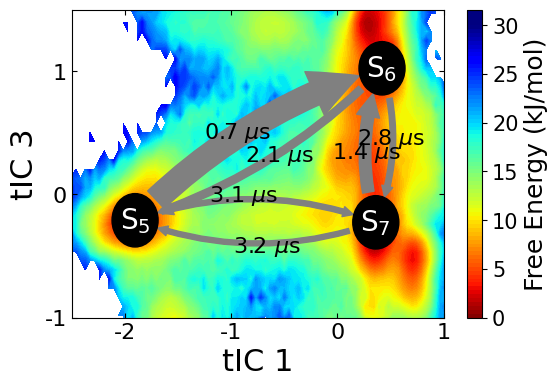

In [15]:
mfpt = np.zeros((7,7), dtype = float)
for i in range(7):
    for j in range(7):
        mfpt[i, j] = M.mfpt(M.metastable_sets[i],M.metastable_sets[j])

mfpt = mfpt[4:,4:]
inverse_mfpt = np.zeros_like(mfpt)
nz = mfpt.nonzero()
inverse_mfpt[nz] = 1.0 / mfpt[nz]
#Calculating the inverse of the mfpt for the arrow size. 
#Smaller the MFPT the larger we draw the arrow. 

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))
tic_cents = np.zeros((3, 2), dtype = float)
#Calculating the macrostate centers for plotting the MFPTs
for i in range(5,8):
    inds = (clust_assign == i)
    tic_cents[i-5,0] = np.average(tica_concat[inds,0], weights = wts_concat[inds])
    tic_cents[i-5,1] = np.average(tica_concat[inds,2], weights = wts_concat[inds])
    
mfpt_labs = mfpt/100000
#Frames are saved at intervals of 10 ps.
#So, dividing by 100000 to convert MFPT to microseconds.
state_labels = []
for i in range(5,8):
    txt = 'S$_{' + str(int(i)) + '}$'
    state_labels.append(txt)
state_sizes = np.asarray([10,10,10])


im = pyemma.plots.plot_free_energy(tica_concat[:,0],tica_concat[:,2], ax = ax, cbar = True, cmap = 'jet_r', weights = wts_concat, cbar_label = 'Energy (kJ/mol)', kT = 2.479, zorder = -1, legacy = False, vmin = 0, vmax = 30)

pyemma.plots.plot_network(inverse_mfpt, pos = tic_cents, arrow_label_format='%.1f $\mu$s',
    arrow_labels=mfpt_labs, state_sizes = state_sizes,
    arrow_scale=3.0, size = 20, color = 'w', arrow_curvature = 2.0,
    state_labels=state_labels, ax = ax, state_colors = 'k', show_frame = True, arrow_label_size = 16)

########################################################################################################
#Plot beautification below this. 
########################################################################################################
yticks = [-5, -4, -3, -2, -1, 0, 1, 2]
xticks = [-3, -2, -1, 0, 1, 2]
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(xticks, fontsize = 16)
ax.set_yticklabels(yticks, fontsize = 16)
ax.tick_params(axis = 'y', direction = 'in', left = True, right = True)
ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = True)
ax.set_xlabel('tIC 1', fontsize = 22)
ax.set_ylabel('tIC 3', fontsize = 22)

cbar_ticks = [0, 5, 10, 15, 20, 25, 30]
im[2]['cbar'].set_ticks(cbar_ticks)
im[2]['cbar'].set_label('Free Energy (kJ/mol)', size = 18)
im[2]['cbar'].ax.tick_params(labelsize = 15)

ax.set_xlim(-2.5,1)
ax.set_ylim(-1,1.5)

ax.set_ylabel('tIC 3', fontsize = 22)
ax.set_xlabel('tIC 1', fontsize = 22)
        

## Step 12
* Calculate any system characteristic along the 3 important macrostates - Demonstrated using MDAnalysis for the N97-E104 Calcium site.

/nethome/asridhar/software/python3.8/lib/python3.8/site-packages/MDAnalysis/coordinates/TRJ.py:1209: DeprecationWarning: Please use `netcdf_file` from the `scipy.io` namespace, the `scipy.io.netcdf` namespace is deprecated.
  class NCDFPicklable(scipy.io.netcdf.netcdf_file):
/nethome/asridhar/software/python3.8/lib/python3.8/site-packages/MDAnalysis/topology/PDBParser.py:317: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
100%|██████████| 2079588/2079588 [15:20<00:00, 2260.00it/s]
/nethome/asridhar/software/python3.8/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:429: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


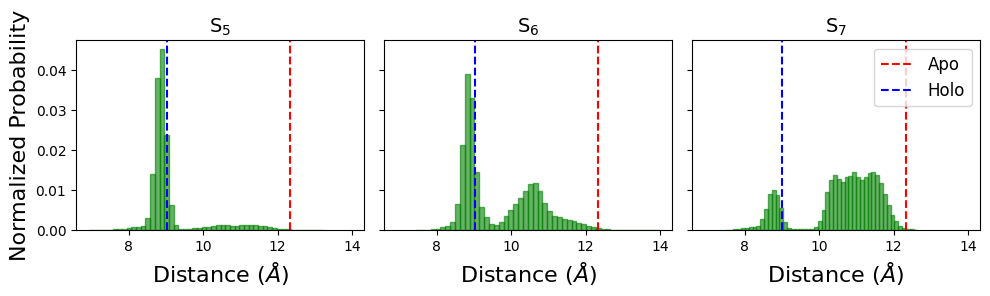

In [16]:
import MDAnalysis
U = MDAnalysis.Universe('CaM_TFP.pdb', 'trjcat.xtc')

res1 = U.select_atoms('resname ASN and resid 97')
res2 = U.select_atoms('resname GLU and resid 104')
CA_data = []
for ts in tqdm(U.trajectory):
    CA_data.append(np.linalg.norm(res1.center_of_mass() - res2.center_of_mass()))

CA_data = np.asarray(CA_data)
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (10,3), sharex = True, sharey = True)

for i in range(5,8):
    inds = (clust_assign == i)
    ax[i-5].hist(CA_data[inds], facecolor = 'g', edgecolor = 'g', alpha = 0.6, bins = 50, weights = wts_concat[inds])   

#######################################################################################
#Now downloading, calculating and plotting the corresponding value for Apo- and Holo-CaM.
#######################################################################################

pdb_structs = ['1CFD','1CLL']
labels = ['Apo', 'Holo']
color = ['red', 'blue']
count = 0

for i in pdb_structs:
    comd = 'wget https://files.rcsb.org/download/' + i + '.pdb'
    os.system(comd)
    
    pdb_file = i + '.pdb'
    U2 = MDAnalysis.Universe(pdb_file)
    res1 = U2.select_atoms('resname ASN and resid 97')
    res2 = U2.select_atoms('resname GLU and resid 104')
    dist = np.linalg.norm(res1.center_of_mass() - res2.center_of_mass())
    
    for j in range(3):
        ax[j].axvline(x = dist, c = color[count], label = labels[count], linestyle = '--', linewidth = 1.5)
        ax[j].set_xlabel('Distance ($\AA$)', fontsize = 16)
        txt = 'S$_{' + str(int(j+5)) + '}$'
        ax[j].set_title(txt, fontsize = 14)
    
    os.remove(pdb_file)
    count = count + 1
    
ax[2].legend(loc = 'upper right', fontsize = 12)
ax[0].set_ylabel('Normalized Probability', fontsize = 16)

plt.tight_layout()

#### For ease of further analysis using the *demystifying* toolkit (https://doi.org/10.1016/j.bpj.2019.12.016), the per-frame inter-residue distances are made available in .npy format.  